In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport 
import warnings
warnings.filterwarnings('ignore') 

In [2]:
df = pd.read_csv('wine.csv')

df.head()


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.describe

<bound method NDFrame.describe of      Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0      14.23        1.71  2.43          15.6        127           2.80   
1      13.20        1.78  2.14          11.2        100           2.65   
2      13.16        2.36  2.67          18.6        101           2.80   
3      14.37        1.95  2.50          16.8        113           3.85   
4      13.24        2.59  2.87          21.0        118           2.80   
..       ...         ...   ...           ...        ...            ...   
173    13.71        5.65  2.45          20.5         95           1.68   
174    13.40        3.91  2.48          23.0        102           1.80   
175    13.27        4.28  2.26          20.0        120           1.59   
176    13.17        2.59  2.37          20.0        120           1.65   
177    14.13        4.10  2.74          24.5         96           2.05   

     Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue

In [4]:
profile = ProfileReport(df, title="Wine Dataset Profiling Report", explorative=True)

profile.to_file("wine_eda_report.html")

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [7]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# K-Means Clustering 

In [8]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  

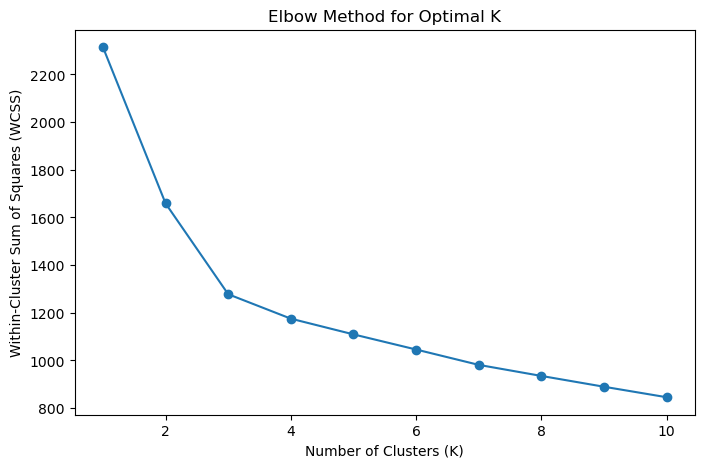

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.show()


In [10]:
optimal_k = 3 
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

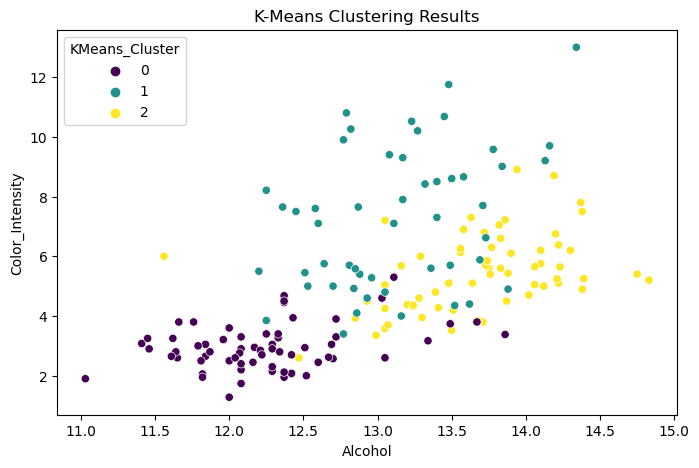

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Alcohol'], y=df['Color_Intensity'], hue=df['KMeans_Cluster'], palette='viridis')
plt.title('K-Means Clustering Results')
plt.show()

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

#  Hierarchical Clustering

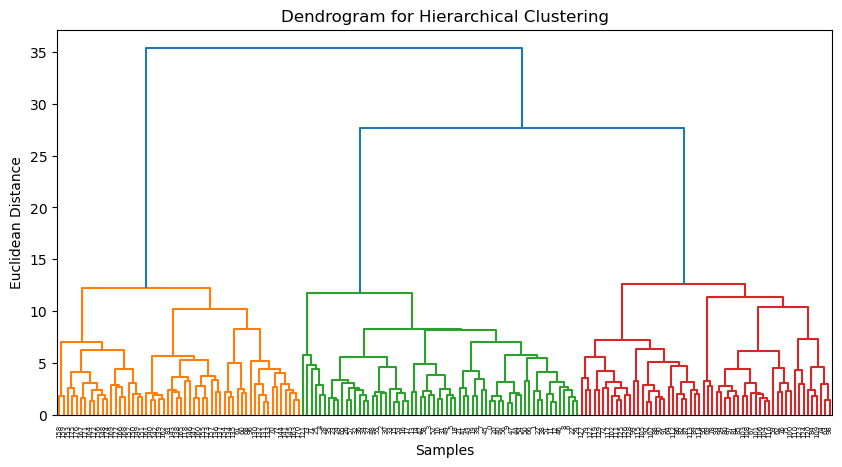

In [13]:
plt.figure(figsize=(10, 5))
linkage_matrix = linkage(df_scaled, method='ward')
dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()


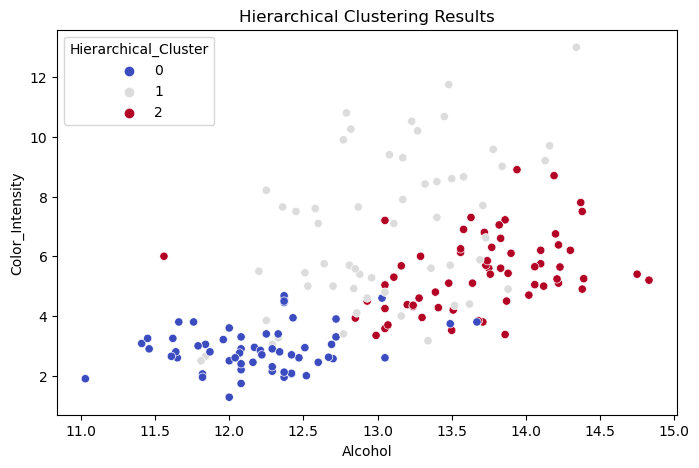

In [14]:
hierarchical = AgglomerativeClustering(n_clusters=3)
df['Hierarchical_Cluster'] = hierarchical.fit_predict(df_scaled)


plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Alcohol'], y=df['Color_Intensity'], hue=df['Hierarchical_Cluster'], palette='coolwarm')
plt.title('Hierarchical Clustering Results')
plt.show()


# DBSCAN Clustering

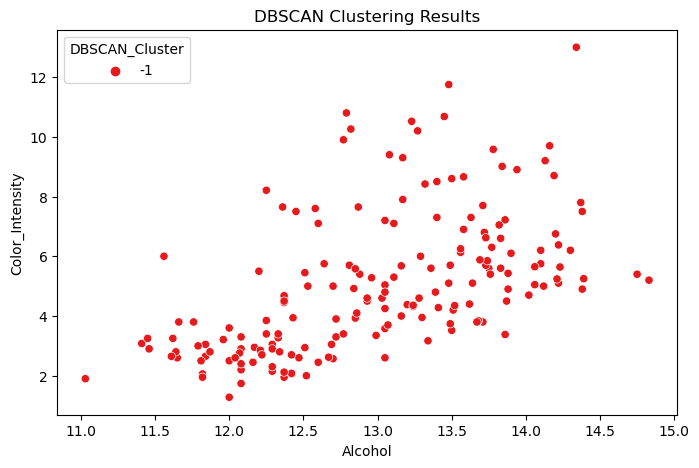

In [15]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)


plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Alcohol'], y=df['Color_Intensity'], hue=df['DBSCAN_Cluster'], palette='Set1')
plt.title('DBSCAN Clustering Results')
plt.show()


In [16]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

In [18]:
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

In [19]:
df_pca['KMeans_Cluster'] = df['KMeans_Cluster']
df_pca['Hierarchical_Cluster'] = df['Hierarchical_Cluster']
df_pca['DBSCAN_Cluster'] = df['DBSCAN_Cluster']


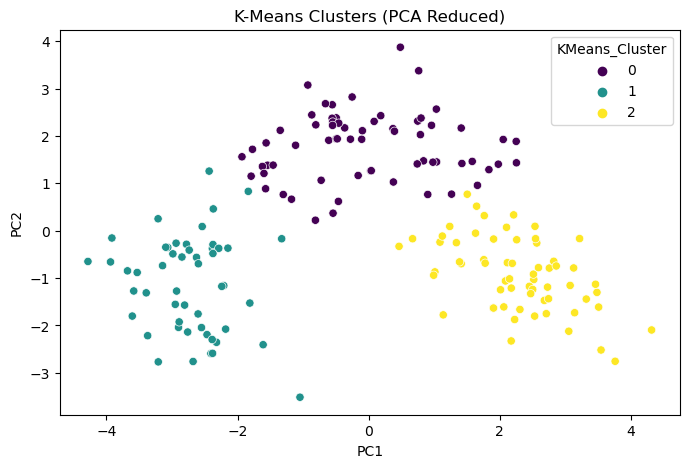

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['KMeans_Cluster'], palette='viridis')
plt.title('K-Means Clusters (PCA Reduced)')
plt.show()

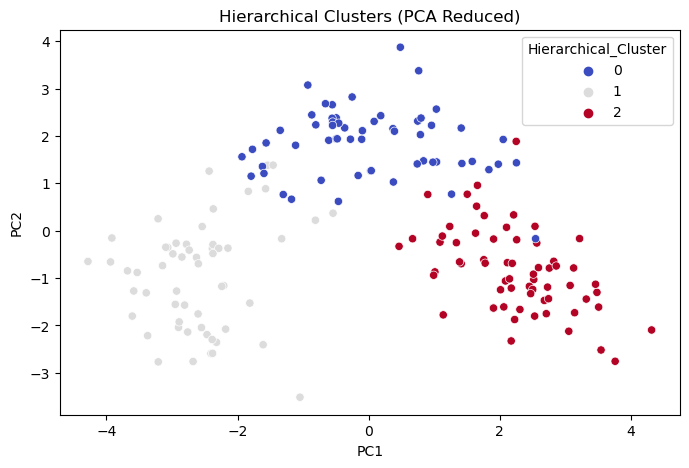

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['Hierarchical_Cluster'], palette='coolwarm')
plt.title('Hierarchical Clusters (PCA Reduced)')
plt.show()


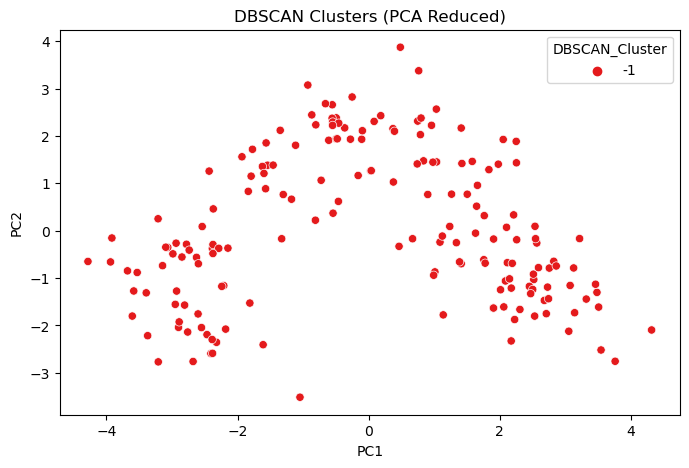

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['DBSCAN_Cluster'], palette='Set1')
plt.title('DBSCAN Clusters (PCA Reduced)')
plt.show()